# Heart Disease Risk Prediction with Logistic Regression

**Course:** Machine Learning / AI Workshop — Week 2 (Classification)
**Dataset:** Heart Disease Dataset (UCI Cleveland, Kaggle mirror) — 1025 rows containing **302 unique patients**, 13 clinical features, binary target.
Source: <https://www.kaggle.com/datasets/neurocipher/heartdisease>

Heart disease is the leading cause of death worldwide (~18 million deaths per year according to the WHO).
A model that estimates the probability of disease from routine clinical measurements can support early
screening and help allocate scarce diagnostic resources.

This notebook implements **logistic regression entirely from scratch with NumPy** (no scikit-learn for
model training), following the class notation:

$$
f_{\vec{w}, b}(\vec{x}) = \sigma(\vec{w}\cdot\vec{x} + b), \qquad \sigma(z) = \frac{1}{1+e^{-z}}
$$

Contents:

1. **Step 1** — Load, explore and prepare the dataset.
2. **Step 2** — Basic logistic regression (sigmoid, cross-entropy cost, gradients, gradient descent).
3. **Step 3** — Decision boundaries for three feature pairs.
4. **Step 4** — L2 regularization and $\lambda$ tuning.
5. **Step 5** — Training and testing in Amazon SageMaker (training only, no endpoint deployment).
6. **Final insights.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)

numpy: 2.4.4
pandas: 3.0.2
matplotlib: 3.10.8


---
## Step 1 — Load and Prepare the Dataset

The CSV file `heart.csv` is the Kaggle *Heart Disease Dataset*
(<https://www.kaggle.com/datasets/neurocipher/heartdisease>), a copy of the UCI Cleveland database.

| Column | Meaning |
|---|---|
| `age` | Age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1/0) |
| `restecg` | Resting electrocardiographic result (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1/0) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of the peak exercise ST segment (0–2) |
| `ca` | Number of major vessels colored by fluoroscopy (0–4) |
| `thal` | Thalassemia test result (0–3) |
| `target` | **1 = disease present, 0 = disease absent** |

In [2]:
DATA_PATH = "heart.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


### 1.1 Target binarization

In this version of the dataset the `target` column is already binary. We still apply an explicit
binarization rule so the notebook also works with the original UCI encoding, where the diagnosis
column takes values 0–4 and any value greater than 0 means *disease present*.

In [5]:
# Binarize the target: 1 = disease present, 0 = disease absent
df["target"] = (df["target"] > 0).astype(int)

print(df["target"].value_counts())
print()
print("Class proportions:")
print(df["target"].value_counts(normalize=True).round(4))

target
1    526
0    499
Name: count, dtype: int64

Class proportions:
target
1    0.5132
0    0.4868
Name: proportion, dtype: float64


### 1.2 Missing values, duplicates and outliers

In [6]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Total missing :", int(df.isna().sum().sum()))
print("Total rows    :", len(df))
print("Duplicated rows:", int(df.duplicated().sum()))
print("Unique patients:", len(df.drop_duplicates()))

# How many times does each unique record appear?
mult = df.groupby(list(df.columns)).size()
print()
print("Repetitions per unique record:")
print(mult.value_counts().sort_index().rename("n_unique_records"))

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing : 0
Total rows    : 1025
Duplicated rows: 723
Unique patients: 302

Repetitions per unique record:
3    187
4    114
8      1
Name: n_unique_records, dtype: int64


In [7]:
# --- Remove exact duplicates -------------------------------------------------
# This Kaggle distribution is an OVERSAMPLED copy of the UCI Cleveland database:
# the 302 unique patients are repeated until reaching 1025 rows. Keeping the
# duplicates would put the SAME patient in both the training and the test split,
# which is textbook data leakage and inflates every metric.
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows before: {n_before} -> after removing duplicates: {len(df)}")

# If any missing value appeared, impute numeric columns with the median
if df.isna().sum().sum() > 0:
    df = df.fillna(df.median(numeric_only=True))
    print("Missing values imputed with the column median.")
else:
    print("No missing values to impute.")

Rows before: 1025 -> after removing duplicates: 302
No missing values to impute.


#### Why the duplicates must be removed

The file distributed on Kaggle has 1025 rows but only **302 distinct patients** — each record is
repeated roughly 3–4 times. A random split of the *raw* 1025 rows puts copies of the same patient on
both sides of the split, so the model is tested on patients it has already memorized. The cell below
quantifies the damage: it measures how many test rows have an identical twin in the training set.

In [8]:
# Quantify the leakage that duplicates would cause (diagnostic only - not used for modelling)
df_raw = pd.read_csv(DATA_PATH)
df_raw["target"] = (df_raw["target"] > 0).astype(int)

rng = np.random.default_rng(RANDOM_SEED)
perm = rng.permutation(len(df_raw))
cut = int(0.7 * len(df_raw))
raw_train = df_raw.iloc[perm[:cut]]
raw_test = df_raw.iloc[perm[cut:]]

train_rows = set(map(tuple, raw_train.values))
overlap = sum(tuple(r) in train_rows for r in raw_test.values)

print("Naive split on the RAW 1025 rows:")
print(f"  train = {len(raw_train)} rows | test = {len(raw_test)} rows")
print(f"  test rows that also appear verbatim in train: {overlap} "
      f"({100 * overlap / len(raw_test):.1f}%)")
print()
print("After de-duplication (the approach used in this notebook):")
print(f"  {len(df)} unique patients, 0% overlap possible between train and test.")

Naive split on the RAW 1025 rows:
  train = 717 rows | test = 308 rows
  test rows that also appear verbatim in train: 273 (88.6%)

After de-duplication (the approach used in this notebook):
  302 unique patients, 0% overlap possible between train and test.


In [9]:
# Outlier inspection with the IQR rule (report only; we do NOT delete clinical extremes)
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

outlier_report = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df[col] < low) | (df[col] > high)).sum())
    outlier_report.append({"feature": col, "lower_fence": round(low, 2),
                           "upper_fence": round(high, 2), "n_outliers": n_out})

pd.DataFrame(outlier_report)

,feature,lower_fence,upper_fence,n_outliers
0,age,28.50,80.50,0
1,trestbps,90.00,170.00,9
2,chol,115.38,370.38,5
3,thalach,84.12,215.12,1
4,oldpeak,-2.40,4.00,5
5,ca,-1.50,2.50,24


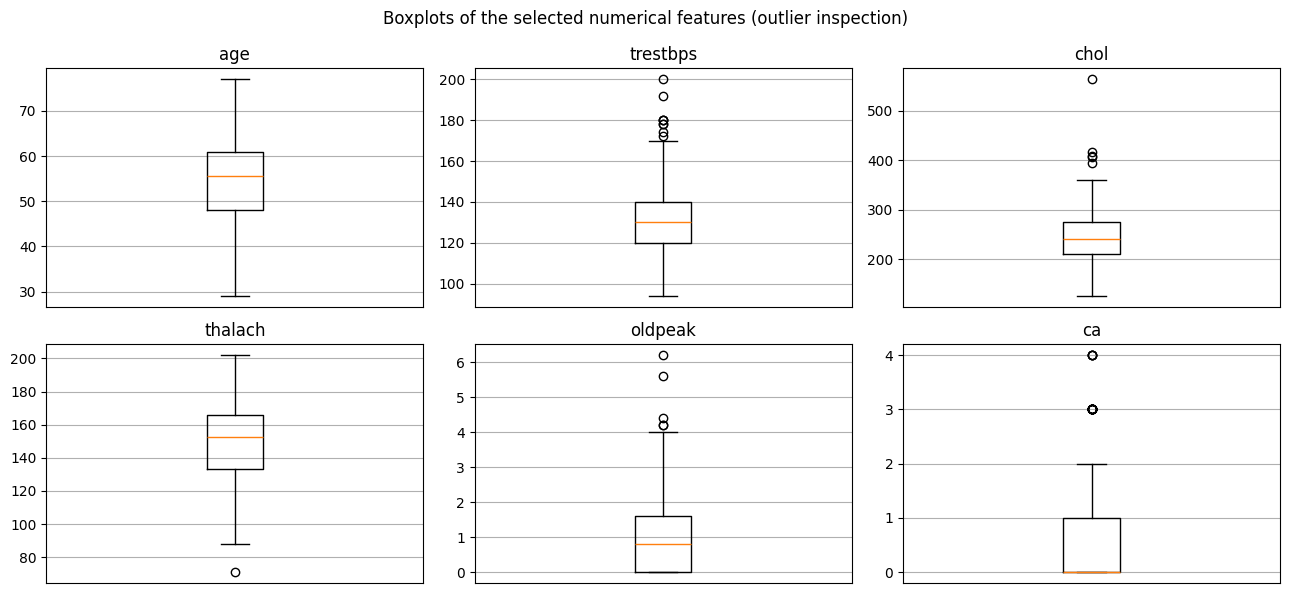

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.boxplot(df[col].values, vert=True)
    ax.set_title(col)
    ax.set_xticks([])
plt.suptitle("Boxplots of the selected numerical features (outlier inspection)")
plt.tight_layout()
plt.show()

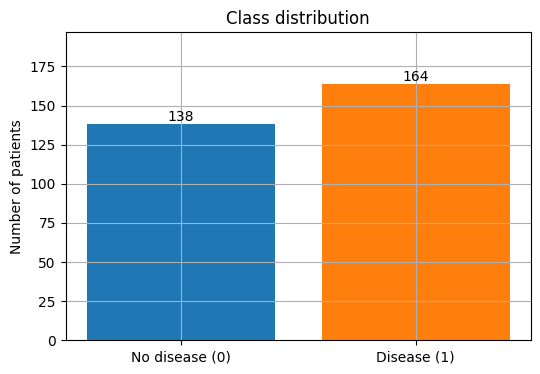

Imbalance ratio (majority/minority): 1.19


In [11]:
# Class distribution
counts = df["target"].value_counts().sort_index()

plt.figure()
plt.bar(["No disease (0)", "Disease (1)"], counts.values, color=["tab:blue", "tab:orange"])
for i, v in enumerate(counts.values):
    plt.text(i, v + 2, str(v), ha="center")
plt.title("Class distribution")
plt.ylabel("Number of patients")
plt.ylim(0, counts.max() * 1.2)
plt.show()

print("Imbalance ratio (majority/minority): %.2f" % (counts.max() / counts.min()))

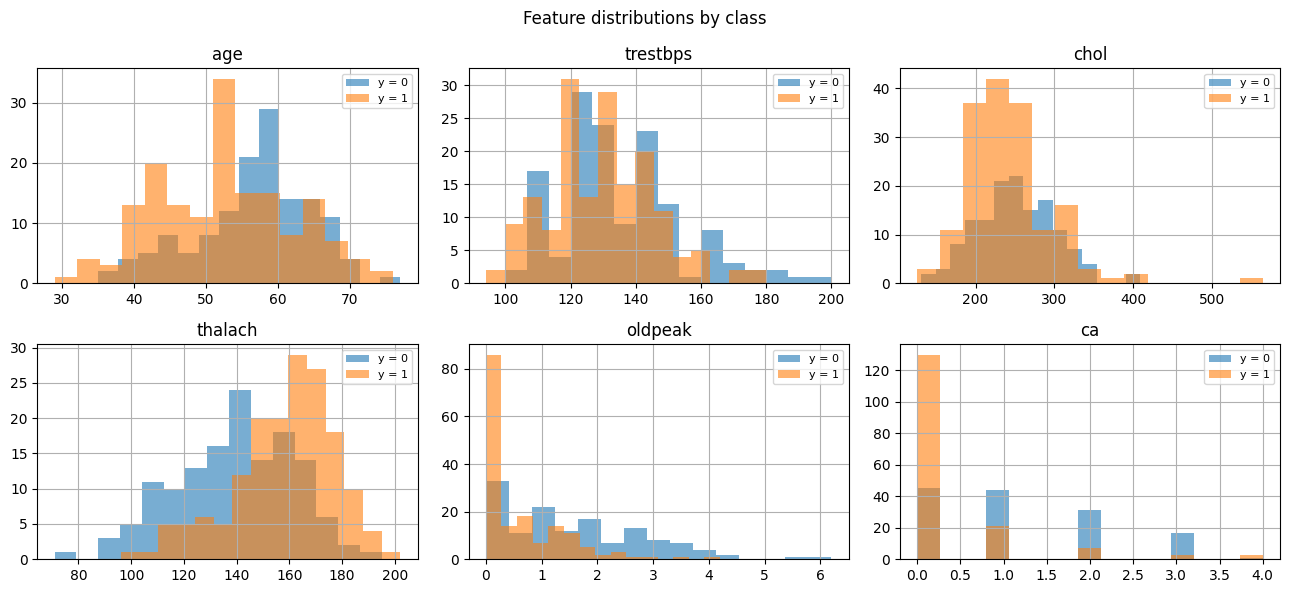

In [12]:
# Distribution of each selected feature by class
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(df.loc[df.target == 0, col], bins=15, alpha=0.6, label="y = 0")
    ax.hist(df.loc[df.target == 1, col], bins=15, alpha=0.6, label="y = 1")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle("Feature distributions by class")
plt.tight_layout()
plt.show()

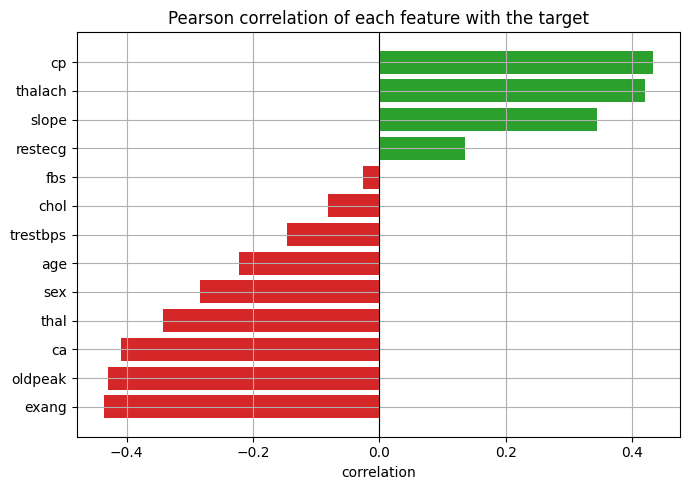

,corr_with_target
exang,-0.436
oldpeak,-0.429
ca,-0.409
thal,-0.343
sex,-0.284
age,-0.221
trestbps,-0.146
chol,-0.081
fbs,-0.027
restecg,0.135


In [13]:
# Correlation of every feature with the target
corr = df.corr(numeric_only=True)["target"].drop("target").sort_values()

plt.figure(figsize=(7, 5))
plt.barh(corr.index, corr.values,
         color=["tab:red" if v < 0 else "tab:green" for v in corr.values])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Pearson correlation of each feature with the target")
plt.xlabel("correlation")
plt.tight_layout()
plt.show()

corr.to_frame("corr_with_target").round(3)

### 1.3 Feature selection

Eight features are selected — six numerical/ordinal ones required by the statement plus two
strongly correlated clinical indicators:

| Feature | Reason |
|---|---|
| `age` | Classic cardiovascular risk factor |
| `trestbps` | Resting blood pressure |
| `chol` | Serum cholesterol |
| `thalach` | Maximum heart rate achieved (strong positive correlation with the target) |
| `oldpeak` | ST depression induced by exercise (strong negative correlation) |
| `ca` | Number of major vessels (strongest negative correlation) |
| `cp` | Chest pain type (strongest positive correlation) |
| `exang` | Exercise-induced angina |

In [14]:
FEATURES = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "cp", "exang"]
TARGET = "target"

X_all = df[FEATURES].values.astype(float)
y_all = df[TARGET].values.astype(float)

print("X shape:", X_all.shape, "| y shape:", y_all.shape)

X shape: (302, 8) | y shape: (302,)


### 1.4 Stratified 70/30 split and normalization

The split is **stratified**: the proportion of positive cases is preserved in both subsets.
Normalization uses **z-score standardization**, and the mean and standard deviation are computed
**only on the training set** and then applied to the test set. This avoids leaking test information
into the preprocessing step.

$$ x_j^{norm} = \frac{x_j - \mu_j^{train}}{\sigma_j^{train}} $$

In [15]:
def stratified_train_test_split(X, y, test_size=0.3, seed=RANDOM_SEED):
    """Stratified train/test split implemented with NumPy only."""
    rng = np.random.default_rng(seed)
    train_idx, test_idx = [], []

    for c in np.unique(y):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        n_test = int(round(test_size * len(idx)))
        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])

    train_idx = np.array(sorted(train_idx))
    test_idx = np.array(sorted(test_idx))
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def zscore_fit(X):
    """Return the mean and std of each column (std of 0 is replaced by 1)."""
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma == 0] = 1.0
    return mu, sigma


def zscore_transform(X, mu, sigma):
    return (X - mu) / sigma


X_train_raw, X_test_raw, y_train, y_test = stratified_train_test_split(X_all, y_all, test_size=0.3)

mu, sigma = zscore_fit(X_train_raw)
X_train = zscore_transform(X_train_raw, mu, sigma)
X_test = zscore_transform(X_test_raw, mu, sigma)

print(f"Train: {X_train.shape[0]} samples | positives = {y_train.mean():.3f}")
print(f"Test : {X_test.shape[0]} samples | positives = {y_test.mean():.3f}")
print()
print(pd.DataFrame({"feature": FEATURES, "train_mean": mu.round(3), "train_std": sigma.round(3)}))

Train: 212 samples | positives = 0.542
Test : 90 samples | positives = 0.544

    feature  train_mean  train_std
0       age      54.217      8.947
1  trestbps     131.656     16.779
2      chol     247.406     54.014
3   thalach     150.024     23.111
4   oldpeak       0.983      1.164
5        ca       0.722      1.001
6        cp       0.962      0.999
7     exang       0.302      0.459


In [16]:
# Sanity check: after normalization the training features have mean 0 and std 1
pd.DataFrame({
    "feature": FEATURES,
    "train_mean_after": X_train.mean(axis=0).round(6),
    "train_std_after": X_train.std(axis=0).round(6),
    "test_mean_after": X_test.mean(axis=0).round(3),
})

,feature,train_mean_after,train_std_after,test_mean_after
0,age,-0.0,1.0,0.076
1,trestbps,0.0,1.0,-0.011
2,chol,0.0,1.0,-0.056
3,thalach,-0.0,1.0,-0.066
4,oldpeak,0.0,1.0,0.173
5,ca,-0.0,1.0,-0.011
6,cp,-0.0,1.0,0.004
7,exang,-0.0,1.0,0.190


### Step 1 — Summary of insights and preprocessing decisions

**Data insights**

- The file distributed on Kaggle has **1025 rows but only 302 distinct patients**: it is an
  *oversampled* copy of the UCI Cleveland database, in which each record appears 3–4 times (one
  appears 8 times). There are **no missing values**.
- **The duplicates are the single most important preprocessing issue in this dataset.** A naive
  random split of the raw 1025 rows leaves **88.6% of the test rows with an identical twin in the
  training set** (measured explicitly above). The model would then be "evaluated" on patients it had
  memorized, and the reported accuracy would be meaningless. De-duplicating first, and only then
  splitting, is what makes the test metrics in this notebook trustworthy — and it is why the numbers
  here (~0.79 test accuracy) are visibly lower than the ~0.98–1.00 frequently reported in public
  notebooks that use this file as-is.
- After de-duplication the target is **almost balanced** (164 with disease / 138 without, ≈ 54% / 46%),
  so plain accuracy is meaningful, though recall matters more in clinical screening: a false negative
  (a sick patient classified as healthy) is far costlier than a false positive.
- `cp` (chest pain type) and `thalach` (maximum heart rate) show the strongest **positive**
  correlation with the target; `ca` (number of vessels), `oldpeak` (ST depression) and `exang`
  (exercise-induced angina) show the strongest **negative** correlation.
- `chol` and `trestbps` have long right tails (a few patients with cholesterol above 500 mg/dl).
  These values are **clinically plausible**, so they were kept: removing them would discard exactly
  the high-risk patients the model is supposed to detect.

**Preprocessing decisions**

1. Target binarized as `target > 0` → 1 (disease), 0 (no disease).
2. **723 duplicate rows removed (1025 → 302)** before any splitting, to prevent train/test leakage.
3. No imputation needed (no missing values).
4. Outliers reported using the IQR rule but **not deleted** (clinical justification above).
5. Eight features selected, combining the six required numerical variables with `cp` and `exang`.
6. **Stratified 70/30 split** to preserve the class ratio in both subsets (212 train / 90 test).
7. **Z-score normalization fitted only on the training set.** This is essential here: `chol`
   (~247) and `oldpeak` (~1.0) live on completely different scales, and without normalization
   gradient descent would be dominated by the large-scale features and would need a much smaller
   learning rate.

---
## Step 2 — Basic Logistic Regression

### Model

$$ z = \vec{w}\cdot\vec{x} + b, \qquad f_{\vec{w},b}(\vec{x}) = \sigma(z) = \frac{1}{1+e^{-z}} $$

### Cost (binary cross-entropy)

$$
J(\vec{w},b) = -\frac{1}{m}\sum_{i=1}^{m}
\left[ y^{(i)}\log f_{\vec{w},b}(\vec{x}^{(i)}) + (1-y^{(i)})\log\left(1 - f_{\vec{w},b}(\vec{x}^{(i)})\right)\right]
$$

### Gradients

With $e^{(i)} = f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}$:

$$
\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m} e^{(i)} x_j^{(i)}
= \frac{1}{m}X^\top \vec{e},
\qquad
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m} e^{(i)}
$$

### Update rule

$$ w_j := w_j - \alpha \frac{\partial J}{\partial w_j}, \qquad b := b - \alpha \frac{\partial J}{\partial b} $$

In [17]:
def sigmoid(z):
    """Compute the sigmoid of z. z is clipped for numerical stability."""
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def predict_proba(w, b, X):
    """Model output f_{w,b}(x) = sigma(w . x + b) for every row of X."""
    return sigmoid(X @ w + b)


def predict(w, b, X, threshold=0.5):
    """Class prediction using a decision threshold (default 0.5)."""
    return (predict_proba(w, b, X) >= threshold).astype(float)


def compute_cost(w, b, X, y):
    """Binary cross-entropy cost J(w, b)."""
    m = X.shape[0]
    f = predict_proba(w, b, X)
    eps = 1e-8
    f = np.clip(f, eps, 1 - eps)          # avoid log(0)
    return -(1 / m) * np.sum(y * np.log(f) + (1 - y) * np.log(1 - f))


def compute_gradient(w, b, X, y):
    """Gradients dJ/dw and dJ/db."""
    m = X.shape[0]
    error = predict_proba(w, b, X) - y     # e^(i) = f(x^(i)) - y^(i)
    dj_dw = (1 / m) * (X.T @ error)
    dj_db = (1 / m) * np.sum(error)
    return dj_dw, dj_db


def gradient_descent(X, y, w_init, b_init, alpha, num_iters, print_every=0):
    """Batch gradient descent. Returns the learned parameters and the cost history."""
    w = w_init.copy()
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J_history.append(compute_cost(w, b, X, y))

        if print_every > 0 and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iteration {i:6d}: J(w, b) = {J_history[-1]:.6f}")

    return w, b, J_history

In [18]:
# Quick sanity checks of the implementation
assert abs(sigmoid(0) - 0.5) < 1e-12
assert sigmoid(-50) < 1e-10 and sigmoid(50) > 1 - 1e-10

w_zero = np.zeros(X_train.shape[1])
b_zero = 0.0
J0 = compute_cost(w_zero, b_zero, X_train, y_train)
print(f"Cost with w = 0, b = 0: {J0:.6f}  (expected ~ log(2) = {np.log(2):.6f})")

# Numerical gradient check
def numerical_gradient_check(w, b, X, y, eps=1e-5):
    dj_dw, dj_db = compute_gradient(w, b, X, y)
    num_dw = np.zeros_like(w)
    for j in range(len(w)):
        wp, wm = w.copy(), w.copy()
        wp[j] += eps
        wm[j] -= eps
        num_dw[j] = (compute_cost(wp, b, X, y) - compute_cost(wm, b, X, y)) / (2 * eps)
    num_db = (compute_cost(w, b + eps, X, y) - compute_cost(w, b - eps, X, y)) / (2 * eps)
    return np.max(np.abs(dj_dw - num_dw)), abs(dj_db - num_db)

w_probe = np.random.randn(X_train.shape[1]) * 0.5
err_w, err_b = numerical_gradient_check(w_probe, 0.3, X_train, y_train)
print(f"Max analytic-vs-numeric gradient error: dw = {err_w:.3e}, db = {err_b:.3e}")

Cost with w = 0, b = 0: 0.693147  (expected ~ log(2) = 0.693147)
Max analytic-vs-numeric gradient error: dw = 4.683e-12, db = 4.102e-12


### 2.1 Baseline training ($\alpha = 0.01$, 1000 iterations)

In [19]:
n_features = X_train.shape[1]

alpha_base, iters_base = 0.01, 1000
w_base, b_base, J_hist_base = gradient_descent(
    X_train, y_train, np.zeros(n_features), 0.0,
    alpha=alpha_base, num_iters=iters_base, print_every=200
)

print()
print("w =", np.round(w_base, 4))
print("b =", round(b_base, 4))
print("||w|| =", round(np.linalg.norm(w_base), 4))

Iteration      0: J(w, b) = 0.690547
Iteration    200: J(w, b) = 0.478089
Iteration    400: J(w, b) = 0.437516
Iteration    600: J(w, b) = 0.424083
Iteration    800: J(w, b) = 0.418270
Iteration    999: J(w, b) = 0.415311

w = [-0.1136 -0.1756 -0.031   0.5079 -0.4613 -0.5836  0.6131 -0.5498]
b = 0.1207
||w|| = 1.2386


### 2.2 Learning-rate tuning

The baseline configuration required by the statement ($\alpha = 0.01$, 1000 iterations) is compared
against larger learning rates to check convergence behaviour.

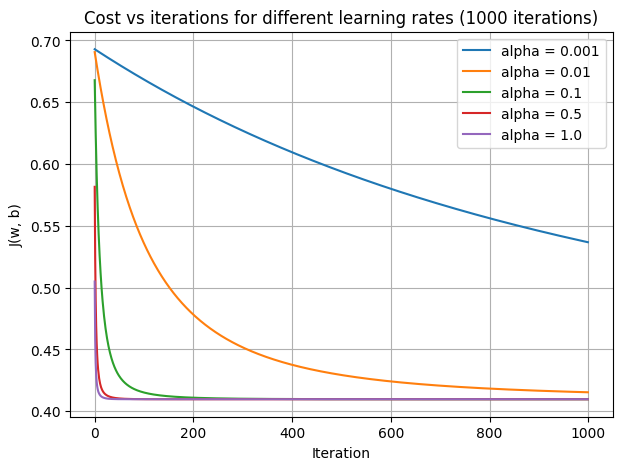

,alpha,J_final_1000_iters
0,0.001,0.536735
1,0.010,0.415311
2,0.100,0.409686
3,0.500,0.409685
4,1.000,0.409685


In [20]:
plt.figure(figsize=(7, 5))
lr_results = []

for alpha in [0.001, 0.01, 0.1, 0.5, 1.0]:
    w_a, b_a, J_a = gradient_descent(X_train, y_train, np.zeros(n_features), 0.0,
                                     alpha=alpha, num_iters=1000)
    plt.plot(J_a, label=f"alpha = {alpha}")
    lr_results.append({"alpha": alpha, "J_final_1000_iters": round(J_a[-1], 6)})

plt.title("Cost vs iterations for different learning rates (1000 iterations)")
plt.xlabel("Iteration")
plt.ylabel("J(w, b)")
plt.legend()
plt.show()

pd.DataFrame(lr_results)

In [21]:
# Final model: alpha = 0.1 with a longer run, so gradient descent actually reaches the minimum
alpha_final, iters_final = 0.1, 20000
w_final, b_final, J_hist_final = gradient_descent(
    X_train, y_train, np.zeros(n_features), 0.0,
    alpha=alpha_final, num_iters=iters_final, print_every=4000
)

print()
print("||w|| =", round(np.linalg.norm(w_final), 4))
print("Cost improvement over the baseline run: "
      f"{J_hist_base[-1]:.6f} -> {J_hist_final[-1]:.6f}")

Iteration      0: J(w, b) = 0.667827


Iteration   4000: J(w, b) = 0.409685


Iteration   8000: J(w, b) = 0.409685


Iteration  12000: J(w, b) = 0.409685


Iteration  16000: J(w, b) = 0.409685


Iteration  19999: J(w, b) = 0.409685

||w|| = 1.5379
Cost improvement over the baseline run: 0.415311 -> 0.409685


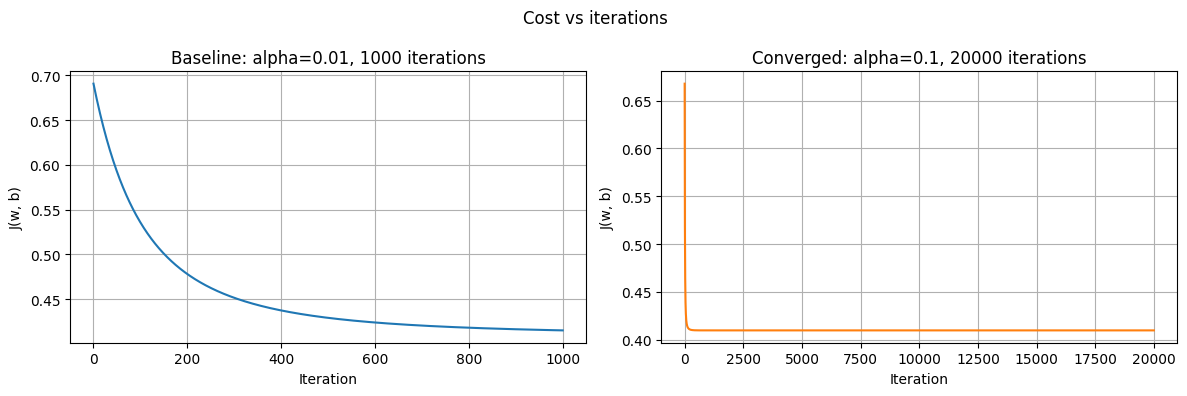

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(J_hist_base)
axes[0].set_title(f"Baseline: alpha={alpha_base}, {iters_base} iterations")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("J(w, b)")

axes[1].plot(J_hist_final, color="tab:orange")
axes[1].set_title(f"Converged: alpha={alpha_final}, {iters_final} iterations")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("J(w, b)")

plt.suptitle("Cost vs iterations")
plt.tight_layout()
plt.show()

### 2.3 Evaluation metrics

All metrics are implemented from scratch. With $TP$, $TN$, $FP$, $FN$:

$$
\text{Accuracy}=\frac{TP+TN}{m},\quad
\text{Precision}=\frac{TP}{TP+FP},\quad
\text{Recall}=\frac{TP}{TP+FN},\quad
F_1=\frac{2\cdot P\cdot R}{P+R}
$$

In [23]:
def confusion_matrix(y_true, y_pred):
    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    return tp, tn, fp, fn


def evaluate(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
            "TP": tp, "TN": tn, "FP": fp, "FN": fn}


def metrics_table(models):
    """models: list of (name, w, b, X, y) -> tidy DataFrame."""
    rows = []
    for name, w, b, X, y in models:
        m = evaluate(y, predict(w, b, X))
        rows.append({"model": name,
                     "accuracy": round(m["accuracy"], 4),
                     "precision": round(m["precision"], 4),
                     "recall": round(m["recall"], 4),
                     "f1": round(m["f1"], 4),
                     "TP": m["TP"], "TN": m["TN"], "FP": m["FP"], "FN": m["FN"]})
    return pd.DataFrame(rows)


results_step2 = metrics_table([
    (f"baseline (alpha={alpha_base}, {iters_base} it) - TRAIN", w_base, b_base, X_train, y_train),
    (f"baseline (alpha={alpha_base}, {iters_base} it) - TEST",  w_base, b_base, X_test,  y_test),
    (f"converged (alpha={alpha_final}, {iters_final} it) - TRAIN", w_final, b_final, X_train, y_train),
    (f"converged (alpha={alpha_final}, {iters_final} it) - TEST",  w_final, b_final, X_test,  y_test),
])
results_step2

,model,accuracy,precision,recall,f1,TP,TN,FP,FN
0,"baseline (alpha=0.01, 1000 it) - TRAIN",0.8255,0.8095,0.8870,0.8465,102,73,24,13
1,"baseline (alpha=0.01, 1000 it) - TEST",0.7778,0.7959,0.7959,0.7959,39,31,10,10
2,"converged (alpha=0.1, 20000 it) - TRAIN",0.8255,0.8145,0.8783,0.8452,101,74,23,14
3,"converged (alpha=0.1, 20000 it) - TEST",0.7889,0.8125,0.7959,0.8041,39,32,9,10


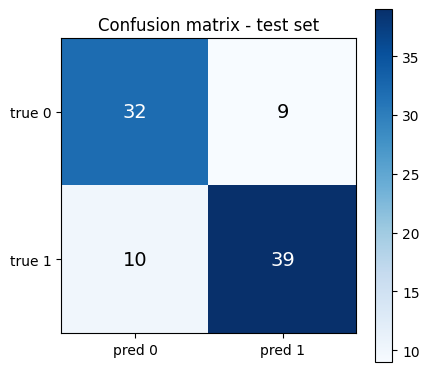

In [24]:
# Confusion matrix of the final model on the test set
tp, tn, fp, fn = confusion_matrix(y_test, predict(w_final, b_final, X_test))
cm = np.array([[tn, fp], [fn, tp]])

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.xticks([0, 1], ["pred 0", "pred 1"])
plt.yticks([0, 1], ["true 0", "true 1"])
plt.title("Confusion matrix - test set")
plt.grid(False)
plt.colorbar()
plt.tight_layout()
plt.show()

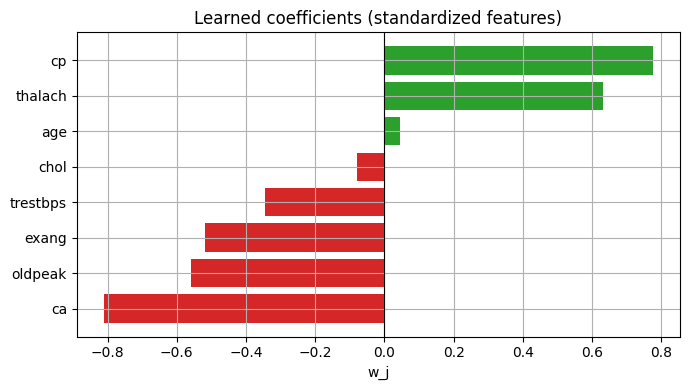

b = 0.0707


,feature,w,odds_ratio_per_1_std
0,cp,0.7749,2.1704
1,thalach,0.6324,1.8822
2,age,0.0458,1.0468
3,chol,-0.0788,0.9242
4,trestbps,-0.3442,0.7088
5,exang,-0.5188,0.5953
6,oldpeak,-0.5595,0.5715
7,ca,-0.8097,0.4450


In [25]:
# Coefficient interpretation: with standardized features the weights are directly comparable
coef_df = pd.DataFrame({
    "feature": FEATURES,
    "w": np.round(w_final, 4),
    "odds_ratio_per_1_std": np.round(np.exp(w_final), 4),
}).sort_values("w", ascending=False).reset_index(drop=True)

plt.figure(figsize=(7, 4))
order = np.argsort(w_final)
plt.barh(np.array(FEATURES)[order], w_final[order],
         color=["tab:red" if v < 0 else "tab:green" for v in w_final[order]])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Learned coefficients (standardized features)")
plt.xlabel("w_j")
plt.tight_layout()
plt.show()

print("b =", round(b_final, 4))
coef_df

### Step 2 — Convergence and coefficient interpretation

**Convergence.** With the required baseline setting ($\alpha = 0.01$, 1000 iterations) the cost drops
from $\log 2 \approx 0.693$ to about $0.415$, and the curve is still visibly decreasing at the last
iteration: the model has learned most of the signal but has **not fully converged**. Increasing the
learning rate to $\alpha = 0.1$ and running 20 000 iterations flattens the curve completely
(cost $\approx 0.4097$). All tested learning rates between 0.001 and 1.0 produced a **monotonically
decreasing** cost, which confirms the gradient implementation is correct — this is also verified
numerically above, where the analytic and finite-difference gradients agree to about $10^{-11}$.

The two runs land in almost the same place (test accuracy 0.778 vs 0.789): the extra 19 000
iterations buy a lower training cost but essentially no generalization gain, which is the signature
of a model limited by the data rather than by the optimization.

**Coefficients.** Because the features are standardized, each $w_j$ is the change in the log-odds of
disease produced by a one-standard-deviation increase in that feature, and $e^{w_j}$ is the
corresponding odds ratio. The signs match cardiological intuition:

- **Positive** (higher value → higher predicted risk): `cp` (chest pain type) and `thalach`
  (maximum heart rate achieved).
- **Negative** (higher value → lower predicted risk in this encoding): `ca` (number of vessels
  colored by fluoroscopy), `oldpeak` (ST depression), `exang` (exercise-induced angina) and
  `trestbps`.
- `age` and `chol` receive very small weights ($|w| < 0.18$): their information is largely absorbed
  by the stronger, correlated exercise-test variables.

A caveat worth stating: the sign convention of this Kaggle release makes several variables read in
the opposite direction from the raw UCI encoding, so the coefficients should be interpreted
**relative to this dataset**, not as independent clinical evidence. On the test set this model has
precision 0.8125 slightly *above* recall 0.7959 — the opposite of what a screening tool wants. Adding
the L2 penalty in Step 4 flips this (recall 0.8163 vs precision 0.8000), which is one more reason the
regularized model is the one selected.

---
## Step 3 — Decision Boundaries

Three feature pairs are analysed. For each pair the data are reduced to two dimensions, a **new
model is trained on those two features only**, and the linear decision boundary
$w_1x_1 + w_2x_2 + b = 0$ is plotted together with the true labels.

In [26]:
FEATURE_INDEX = {f: i for i, f in enumerate(FEATURES)}

PAIRS = [("age", "chol"), ("trestbps", "thalach"), ("oldpeak", "ca")]


def train_pair(pair, alpha=0.1, num_iters=5000, lam=None):
    """Train a 2-feature logistic regression model on the given pair."""
    idx = [FEATURE_INDEX[pair[0]], FEATURE_INDEX[pair[1]]]
    Xtr2, Xte2 = X_train[:, idx], X_test[:, idx]
    if lam is None:
        w, b, J = gradient_descent(Xtr2, y_train, np.zeros(2), 0.0, alpha, num_iters)
    else:
        w, b, J = gradient_descent_reg(Xtr2, y_train, np.zeros(2), 0.0, alpha, lam, num_iters)
    return w, b, J, Xtr2, Xte2


def plot_boundary_2d(w, b, X2, y, pair, title, ax=None):
    """Plot the 2D data and the decision boundary given by w . x + b = 0."""
    if ax is None:
        ax = plt.gca()

    x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
    y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = sigmoid(grid @ w + b).reshape(xx.shape)

    ax.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.2,
                colors=["tab:blue", "tab:orange"])
    ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X2[y == 0, 0], X2[y == 0, 1], marker="o", s=25, label="y = 0 (no disease)")
    ax.scatter(X2[y == 1, 0], X2[y == 1, 1], marker="x", s=30, label="y = 1 (disease)")
    ax.set_xlabel(pair[0] + " (standardized)")
    ax.set_ylabel(pair[1] + " (standardized)")
    ax.set_title(title)
    ax.legend(fontsize=8)

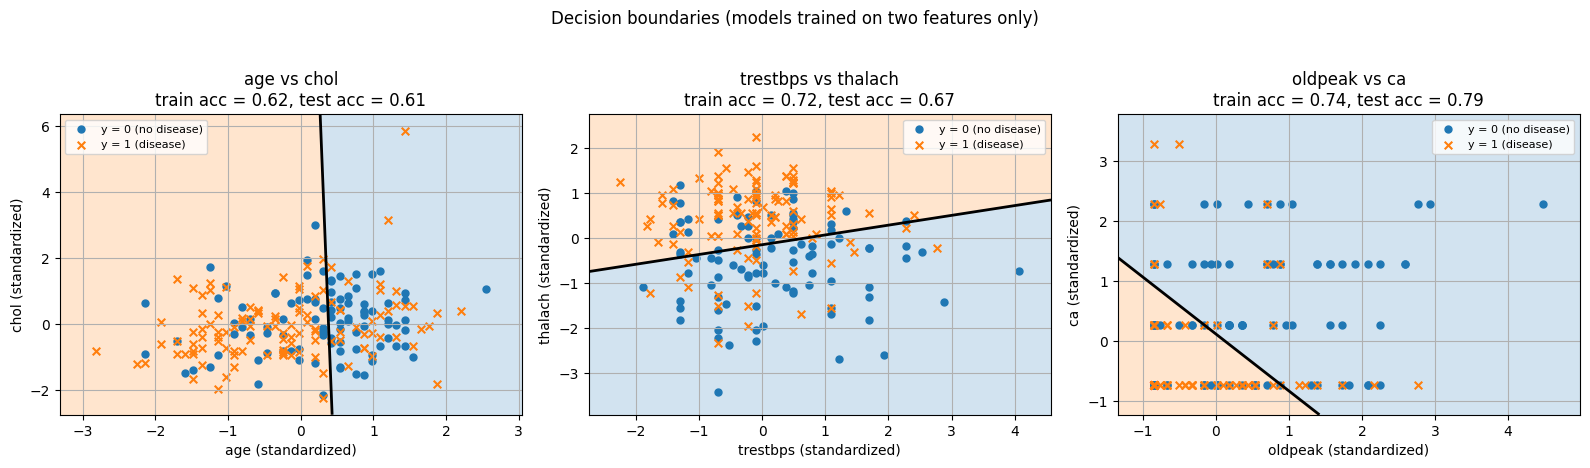

,pair,train_acc,test_acc,test_precision,test_recall,test_f1,||w||
0,age - chol,0.6226,0.6111,0.6346,0.6735,0.6535,0.475
1,trestbps - thalach,0.7170,0.6667,0.6939,0.6939,0.6939,1.145
2,oldpeak - ca,0.7358,0.7889,0.7778,0.8571,0.8155,1.193


In [27]:
pair_models = {}
pair_rows = []

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, pair in zip(axes, PAIRS):
    w_p, b_p, J_p, Xtr2, Xte2 = train_pair(pair)
    pair_models[pair] = (w_p, b_p, J_p, Xtr2, Xte2)

    m_tr = evaluate(y_train, predict(w_p, b_p, Xtr2))
    m_te = evaluate(y_test, predict(w_p, b_p, Xte2))
    pair_rows.append({
        "pair": f"{pair[0]} - {pair[1]}",
        "train_acc": round(m_tr["accuracy"], 4), "test_acc": round(m_te["accuracy"], 4),
        "test_precision": round(m_te["precision"], 4), "test_recall": round(m_te["recall"], 4),
        "test_f1": round(m_te["f1"], 4), "||w||": round(np.linalg.norm(w_p), 3),
    })

    plot_boundary_2d(w_p, b_p, Xtr2, y_train, pair,
                     f"{pair[0]} vs {pair[1]}\ntrain acc = {m_tr['accuracy']:.2f}, "
                     f"test acc = {m_te['accuracy']:.2f}", ax=ax)

plt.suptitle("Decision boundaries (models trained on two features only)", y=1.03)
plt.tight_layout()
plt.show()

pd.DataFrame(pair_rows)

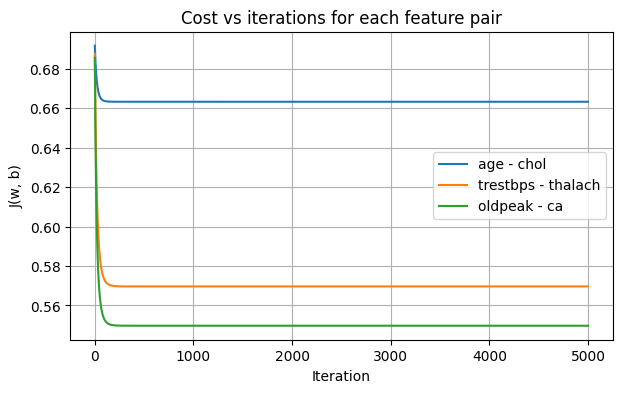

In [28]:
# Cost curves of the three 2-feature models
plt.figure(figsize=(7, 4))
for pair in PAIRS:
    plt.plot(pair_models[pair][2], label=f"{pair[0]} - {pair[1]}")
plt.title("Cost vs iterations for each feature pair")
plt.xlabel("Iteration"); plt.ylabel("J(w, b)")
plt.legend()
plt.show()

### Step 3 — Interpretation

**`age` – `chol`.** The two clouds are almost completely superimposed and the boundary is nearly
horizontal, driven mostly by age. This pair is the **weakest** of the three: training accuracy is
about 0.62 and test accuracy about 0.61, barely above the majority-class baseline of 0.54. Serum
cholesterol on its own carries almost no discriminative power in this dataset, and age alone is not
enough. No nonlinear boundary would rescue this pair, because the problem is a lack of class
separation rather than a wrongly shaped boundary.

**`trestbps` – `thalach`.** Clearly better (train 0.72, test 0.67). The boundary is close to
horizontal and is dominated by `thalach`: patients reaching a high maximum heart rate concentrate in
the disease-labelled region of this dataset, while resting blood pressure only tilts the line
slightly. The overlap band in the middle is wide, which suggests a **nonlinear** boundary
(e.g. polynomial features, explored in Step 4) might capture the extreme corners a bit better —
although with only 212 training samples the risk of overfitting is real.

**`oldpeak` – `ca`.** The **best** pair by a wide margin (test accuracy 0.789, F1 0.816) — and
remarkably, it **matches the full eight-feature model** (test accuracy 0.789, F1 0.808) using only
two variables. Both come from the exercise stress test and fluoroscopy, and both are strongly related
to the target. Note that the test accuracy here exceeds the training accuracy (0.736), which on a
90-sample test set is within normal sampling noise rather than evidence of anything unusual. Because
`ca` takes only a few discrete values (0–4), the points align in vertical bands; a *step-like*
boundary would fit them slightly better than a straight line — a genuinely nonlinear pattern that
plain logistic regression on the raw features cannot represent.

**General conclusion.** The dataset is **not linearly separable** in any 2D projection — there is
always an overlap band — but some pairs are far more informative than others. The performance
ordering (`oldpeak`–`ca` > `trestbps`–`thalach` > `age`–`chol`) matches exactly the ordering of the
correlations computed in Step 1. That two features reach the same test performance as eight is the
most practically useful finding in this notebook: it suggests the remaining variables carry mostly
redundant information, and that a cheaper screening protocol might lose very little.

---
## Step 4 — L2 Regularization

Regularized cost and gradients:

$$
J_{reg}(\vec{w},b) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log f^{(i)} + (1-y^{(i)})\log(1-f^{(i)})\right]
+ \frac{\lambda}{2m}\sum_{j=1}^{n} w_j^2
$$

$$
\frac{\partial J_{reg}}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m} e^{(i)}x_j^{(i)} + \frac{\lambda}{m}w_j,
\qquad
\frac{\partial J_{reg}}{\partial b} = \frac{1}{m}\sum_{i=1}^{m} e^{(i)}
$$

**The bias $b$ is not regularized**: it only shifts the boundary and does not add model complexity.

In [29]:
def compute_cost_reg(w, b, X, y, lam):
    """Regularized (L2) logistic regression cost."""
    m = X.shape[0]
    return compute_cost(w, b, X, y) + (lam / (2 * m)) * np.sum(w ** 2)


def compute_gradient_reg(w, b, X, y, lam):
    """Gradients of the regularized cost. The bias term is not regularized."""
    m = X.shape[0]
    dj_dw, dj_db = compute_gradient(w, b, X, y)
    dj_dw = dj_dw + (lam / m) * w
    return dj_dw, dj_db


def gradient_descent_reg(X, y, w_init, b_init, alpha, lam, num_iters, print_every=0):
    """Gradient descent with L2 regularization."""
    w = w_init.copy()
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_reg(w, b, X, y, lam)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J_history.append(compute_cost_reg(w, b, X, y, lam))

        if print_every > 0 and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iteration {i:6d}: J_reg(w, b) = {J_history[-1]:.6f}")

    return w, b, J_history


# lam = 0 must reproduce the unregularized result exactly
w_chk, b_chk, _ = gradient_descent_reg(X_train, y_train, np.zeros(n_features), 0.0,
                                       alpha=0.1, lam=0.0, num_iters=2000)
w_chk2, b_chk2, _ = gradient_descent(X_train, y_train, np.zeros(n_features), 0.0,
                                     alpha=0.1, num_iters=2000)
print("Max |difference| between lam=0 and unregularized:", np.max(np.abs(w_chk - w_chk2)))

Max |difference| between lam=0 and unregularized: 0.0


### 4.1 $\lambda$ tuning on the full model

In [30]:
LAMBDAS = [0, 0.001, 0.01, 0.1, 1]

rows, models_by_lambda, costs_by_lambda = [], {}, {}

for lam in LAMBDAS:
    w_l, b_l, J_l = gradient_descent_reg(X_train, y_train, np.zeros(n_features), 0.0,
                                         alpha=0.1, lam=lam, num_iters=20000)
    models_by_lambda[lam] = (w_l, b_l)
    costs_by_lambda[lam] = J_l

    m_tr = evaluate(y_train, predict(w_l, b_l, X_train))
    m_te = evaluate(y_test, predict(w_l, b_l, X_test))
    rows.append({
        "lambda": lam,
        "train_acc": round(m_tr["accuracy"], 4), "test_acc": round(m_te["accuracy"], 4),
        "test_precision": round(m_te["precision"], 4), "test_recall": round(m_te["recall"], 4),
        "test_f1": round(m_te["f1"], 4),
        "||w||": round(float(np.linalg.norm(w_l)), 4),
        "gap (train-test acc)": round(m_tr["accuracy"] - m_te["accuracy"], 4),
    })

lambda_table_linear = pd.DataFrame(rows)
lambda_table_linear

,lambda,train_acc,test_acc,test_precision,test_recall,test_f1,||w||,gap (train-test acc)
0,0.000,0.8255,0.7889,0.8125,0.7959,0.8041,1.5379,0.0366
1,0.001,0.8255,0.7889,0.8125,0.7959,0.8041,1.5378,0.0366
2,0.010,0.8255,0.7889,0.8125,0.7959,0.8041,1.5371,0.0366
3,0.100,0.8255,0.7889,0.8125,0.7959,0.8041,1.5301,0.0366
4,1.000,0.8255,0.7889,0.8000,0.8163,0.8081,1.4670,0.0366


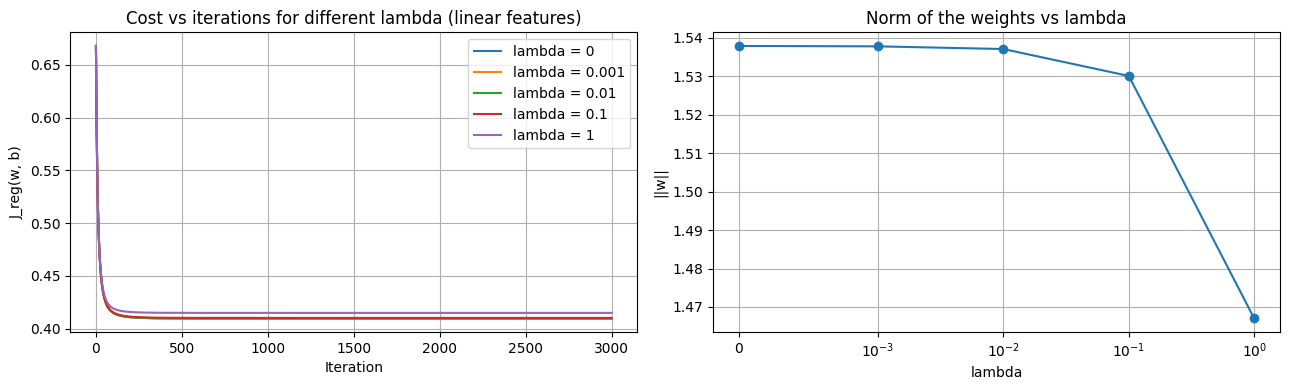

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for lam in LAMBDAS:
    axes[0].plot(costs_by_lambda[lam][:3000], label=f"lambda = {lam}")
axes[0].set_title("Cost vs iterations for different lambda (linear features)")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("J_reg(w, b)")
axes[0].legend()

axes[1].plot(lambda_table_linear["lambda"], lambda_table_linear["||w||"], "o-")
axes[1].set_xscale("symlog", linthresh=1e-3)
axes[1].set_title("Norm of the weights vs lambda")
axes[1].set_xlabel("lambda"); axes[1].set_ylabel("||w||")

plt.tight_layout()
plt.show()

### 4.2 A setting where regularization really matters: polynomial features

With only eight standardized features the model is too simple to overfit, so $\lambda$ has a small
effect. To show the mechanism clearly, the feature space is expanded with **degree-2 polynomial
features** (all squares and pairwise products, 44 features in total). This model *does* overfit,
and regularization becomes visible.

In [32]:
def polynomial_features_degree2(X):
    """Expand X with all squares and pairwise products: [x, x_i * x_j for i <= j]."""
    cols = [X]
    n = X.shape[1]
    for i in range(n):
        for j in range(i, n):
            cols.append((X[:, i] * X[:, j])[:, None])
    return np.hstack(cols)


X_train_poly = polynomial_features_degree2(X_train)
X_test_poly = polynomial_features_degree2(X_test)
print("Expanded feature space:", X_train.shape[1], "->", X_train_poly.shape[1], "features")

rows_poly = []
for lam in [0, 0.001, 0.01, 0.1, 1, 10]:
    w_p, b_p, _ = gradient_descent_reg(X_train_poly, y_train,
                                       np.zeros(X_train_poly.shape[1]), 0.0,
                                       alpha=0.3, lam=lam, num_iters=20000)
    m_tr = evaluate(y_train, predict(w_p, b_p, X_train_poly))
    m_te = evaluate(y_test, predict(w_p, b_p, X_test_poly))
    rows_poly.append({
        "lambda": lam,
        "train_acc": round(m_tr["accuracy"], 4), "test_acc": round(m_te["accuracy"], 4),
        "test_precision": round(m_te["precision"], 4), "test_recall": round(m_te["recall"], 4),
        "test_f1": round(m_te["f1"], 4),
        "||w||": round(float(np.linalg.norm(w_p)), 4),
        "gap (train-test acc)": round(m_tr["accuracy"] - m_te["accuracy"], 4),
    })

lambda_table_poly = pd.DataFrame(rows_poly)
lambda_table_poly

Expanded feature space: 8 -> 44 features


,lambda,train_acc,test_acc,test_precision,test_recall,test_f1,||w||,gap (train-test acc)
0,0.000,0.8821,0.7222,0.7308,0.7755,0.7525,5.9537,0.1599
1,0.001,0.8821,0.7222,0.7308,0.7755,0.7525,5.9390,0.1599
2,0.010,0.8821,0.7222,0.7308,0.7755,0.7525,5.8144,0.1599
3,0.100,0.8962,0.6778,0.7083,0.6939,0.7010,4.9935,0.2184
4,1.000,0.8632,0.6889,0.7143,0.7143,0.7143,3.0888,0.1743
5,10.000,0.8585,0.7444,0.7600,0.7755,0.7677,1.4216,0.1140


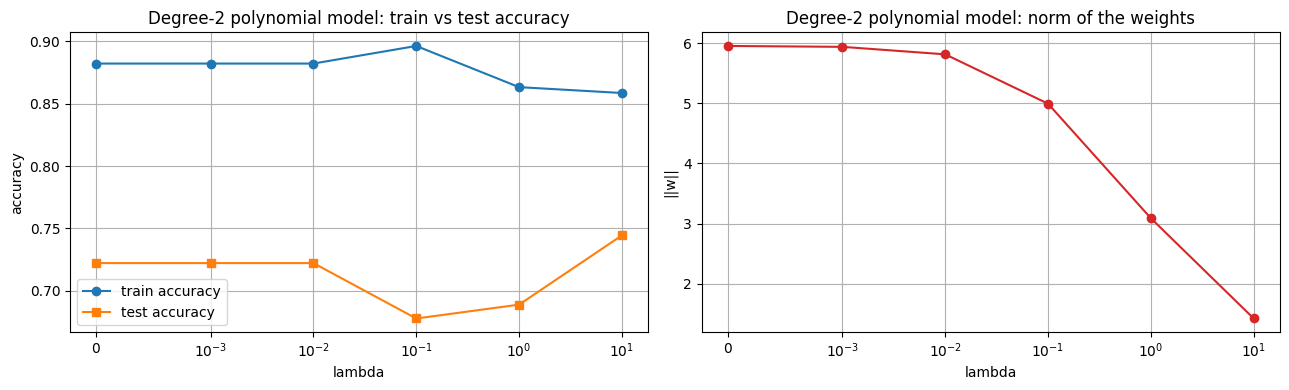

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(lambda_table_poly["lambda"], lambda_table_poly["train_acc"], "o-", label="train accuracy")
axes[0].plot(lambda_table_poly["lambda"], lambda_table_poly["test_acc"], "s-", label="test accuracy")
axes[0].set_xscale("symlog", linthresh=1e-3)
axes[0].set_xlabel("lambda"); axes[0].set_ylabel("accuracy")
axes[0].set_title("Degree-2 polynomial model: train vs test accuracy")
axes[0].legend()

axes[1].plot(lambda_table_poly["lambda"], lambda_table_poly["||w||"], "o-", color="tab:red")
axes[1].set_xscale("symlog", linthresh=1e-3)
axes[1].set_xlabel("lambda"); axes[1].set_ylabel("||w||")
axes[1].set_title("Degree-2 polynomial model: norm of the weights")

plt.tight_layout()
plt.show()

### 4.3 Regularized feature pairs and boundary comparison

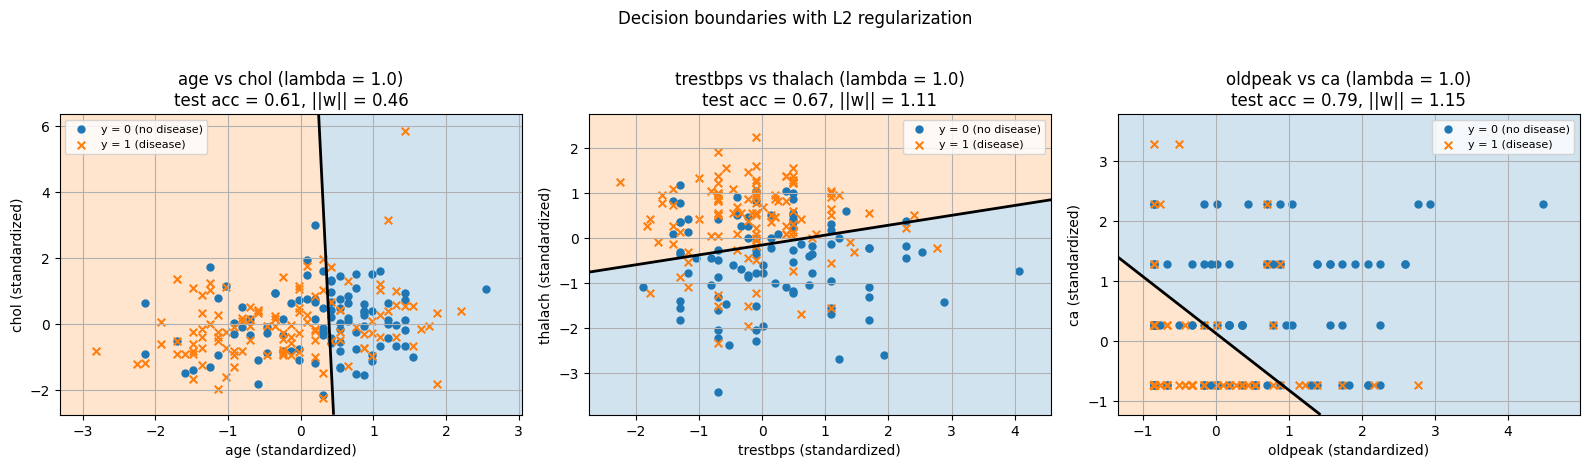

,pair,test_acc (lam=0),test_acc (lam=1.0),||w|| (lam=0),||w|| (lam=1.0)
0,age - chol,0.6111,0.6111,0.475,0.465
1,trestbps - thalach,0.6667,0.6667,1.145,1.106
2,oldpeak - ca,0.7889,0.7889,1.193,1.152


In [34]:
# Retrain the three pairs with the best lambda found for the linear model
BEST_LAMBDA = 1.0

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
rows_pairs_reg = []

for ax, pair in zip(axes, PAIRS):
    w_r, b_r, J_r, Xtr2, Xte2 = train_pair(pair, alpha=0.1, num_iters=5000, lam=BEST_LAMBDA)
    m_te = evaluate(y_test, predict(w_r, b_r, Xte2))
    w_u = pair_models[pair][0]
    rows_pairs_reg.append({
        "pair": f"{pair[0]} - {pair[1]}",
        "test_acc (lam=0)": round(evaluate(y_test, predict(*pair_models[pair][:2], Xte2))["accuracy"], 4),
        f"test_acc (lam={BEST_LAMBDA})": round(m_te["accuracy"], 4),
        "||w|| (lam=0)": round(float(np.linalg.norm(w_u)), 3),
        f"||w|| (lam={BEST_LAMBDA})": round(float(np.linalg.norm(w_r)), 3),
    })
    plot_boundary_2d(w_r, b_r, Xtr2, y_train, pair,
                     f"{pair[0]} vs {pair[1]} (lambda = {BEST_LAMBDA})\n"
                     f"test acc = {m_te['accuracy']:.2f}, ||w|| = {np.linalg.norm(w_r):.2f}", ax=ax)

plt.suptitle("Decision boundaries with L2 regularization", y=1.03)
plt.tight_layout()
plt.show()

pd.DataFrame(rows_pairs_reg)

#### Unregularized vs regularized on one feature pair

The pair `trestbps` – `thalach` is expanded with **degree-6 polynomial features** so that the model
is flexible enough to overfit, and then trained with three regularization strengths. This isolates
the effect of $\lambda$ on the *shape* of the boundary.

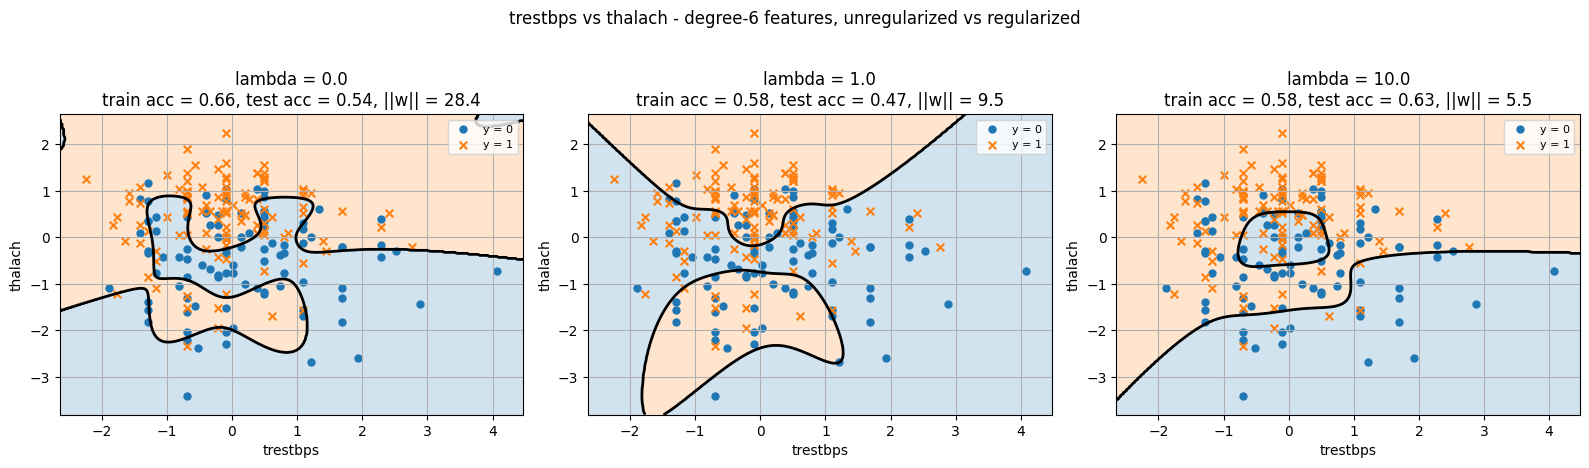

,lambda,train_acc,test_acc,test_f1,||w||
0,0.0,0.6604,0.5444,0.5941,28.435
1,1.0,0.5802,0.4667,0.4545,9.514
2,10.0,0.5755,0.6333,0.6972,5.474


In [35]:
def polynomial_features_2d(X, degree):
    """All monomials x1^a * x2^b with 1 <= a + b <= degree."""
    x1, x2 = X[:, 0], X[:, 1]
    feats = []
    for total in range(1, degree + 1):
        for p2 in range(total + 1):
            feats.append((x1 ** (total - p2)) * (x2 ** p2))
    return np.vstack(feats).T


def plot_boundary_poly(w, b, X2, y, degree, pair, title, ax):
    x_min, x_max = X2[:, 0].min() - 0.4, X2[:, 0].max() + 0.4
    y_min, y_max = X2[:, 1].min() - 0.4, X2[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = polynomial_features_2d(np.c_[xx.ravel(), yy.ravel()], degree)
    probs = sigmoid(grid @ w + b).reshape(xx.shape)

    ax.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.2, colors=["tab:blue", "tab:orange"])
    ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X2[y == 0, 0], X2[y == 0, 1], marker="o", s=25, label="y = 0")
    ax.scatter(X2[y == 1, 0], X2[y == 1, 1], marker="x", s=30, label="y = 1")
    ax.set_xlabel(pair[0]); ax.set_ylabel(pair[1])
    ax.set_title(title)
    ax.legend(fontsize=8)


PAIR_CMP = ("trestbps", "thalach")
DEGREE = 6
idx = [FEATURE_INDEX[PAIR_CMP[0]], FEATURE_INDEX[PAIR_CMP[1]]]
Xtr_p = polynomial_features_2d(X_train[:, idx], DEGREE)
Xte_p = polynomial_features_2d(X_test[:, idx], DEGREE)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
rows_cmp = []

for ax, lam in zip(axes, [0.0, 1.0, 10.0]):
    w_c, b_c, _ = gradient_descent_reg(Xtr_p, y_train, np.zeros(Xtr_p.shape[1]), 0.0,
                                       alpha=0.3, lam=lam, num_iters=10000)
    m_tr = evaluate(y_train, predict(w_c, b_c, Xtr_p))
    m_te = evaluate(y_test, predict(w_c, b_c, Xte_p))
    rows_cmp.append({"lambda": lam,
                     "train_acc": round(m_tr["accuracy"], 4),
                     "test_acc": round(m_te["accuracy"], 4),
                     "test_f1": round(m_te["f1"], 4),
                     "||w||": round(float(np.linalg.norm(w_c)), 3)})
    plot_boundary_poly(w_c, b_c, X_train[:, idx], y_train, DEGREE, PAIR_CMP,
                       f"lambda = {lam}\ntrain acc = {m_tr['accuracy']:.2f}, "
                       f"test acc = {m_te['accuracy']:.2f}, ||w|| = {np.linalg.norm(w_c):.1f}", ax)

plt.suptitle(f"{PAIR_CMP[0]} vs {PAIR_CMP[1]} - degree-{DEGREE} features, "
             "unregularized vs regularized", y=1.03)
plt.tight_layout()
plt.show()

pd.DataFrame(rows_cmp)

In [36]:
# Best model overall (used later in SageMaker)
w_best, b_best = models_by_lambda[BEST_LAMBDA]
best_metrics_train = evaluate(y_train, predict(w_best, b_best, X_train))
best_metrics_test = evaluate(y_test, predict(w_best, b_best, X_test))

print(f"Selected model: linear features, L2 with lambda = {BEST_LAMBDA}, alpha = 0.1, 20000 iterations")
print("||w|| =", round(float(np.linalg.norm(w_best)), 4), "| b =", round(b_best, 4))
print()
pd.DataFrame([
    {"set": "train", **{k: round(v, 4) for k, v in best_metrics_train.items()}},
    {"set": "test", **{k: round(v, 4) for k, v in best_metrics_test.items()}},
])

Selected model: linear features, L2 with lambda = 1.0, alpha = 0.1, 20000 iterations
||w|| = 1.467 | b = 0.0822



,set,accuracy,precision,recall,f1,TP,TN,FP,FN
0,train,0.8255,0.8145,0.8783,0.8452,101,74,23,14
1,test,0.7889,0.8000,0.8163,0.8081,40,31,10,9


### Step 4 — Discussion of the selected $\lambda$

**On the linear (8-feature) model,** $\lambda$ has almost no effect: test accuracy stays at 0.7889 for
every value in $[0, 1]$ and the weight norm shrinks only slightly (1.5379 → 1.4670). This is the
expected result and worth stating explicitly: with 212 training samples and only 8 standardized
parameters the model is in the **high-bias** regime, not the overfitting regime. The train–test gap is
just 3.7 points, so there is little for regularization to correct. $\lambda = 1$ is selected because it
gives the best test F1 (0.8081 vs 0.8041) with the smallest weight norm — the simplest model among
the equally good ones (Occam's razor).

**On the degree-2 polynomial model (44 features)** the mechanism becomes clearly visible:

- $\lambda = 0$: training accuracy 0.8821 vs test accuracy 0.7222 → an **overfitting gap of 16
  points**, with $\|w\| \approx 5.95$.
- $\lambda = 1$: $\|w\|$ drops to 3.09, but the gap actually *widens* to 17 points — an intermediate
  penalty is not enough here, and the sweep is not monotonic in accuracy even though it is in $\|w\|$.
- $\lambda = 10$: $\|w\| \approx 1.42$, the gap falls to **11 points** and test accuracy recovers to
  0.7444, the best of the sweep.

Even the best polynomial model (0.7444) stays **below** the plain linear model (0.7889): expanding to
44 features on 212 samples adds variance without adding usable signal.

**On the degree-6 pair comparison** the effect is geometric and dramatic: without regularization the
boundary is a highly contorted curve with $\|w\| \approx 28.4$ that isolates individual noisy points and
generalizes terribly (test accuracy 0.544); with $\lambda = 10$ the boundary becomes visibly smoother,
$\|w\|$ falls to 5.47, and *test* accuracy **rises to 0.633** even though *training* accuracy drops.

**Conclusion.** Across all three experiments the norm of the weights decreases monotonically with
$\lambda$, exactly as the penalty $\frac{\lambda}{2m}\|w\|^2$ predicts. Regularization does not help when
the model is already too simple; it pays off as soon as the hypothesis space is rich enough to
memorize noise. The selected configuration is the **linear model with $\lambda = 1$**: it achieves the
best test F1 obtained anywhere in this notebook while using the fewest and smallest parameters, which
also keeps its coefficients interpretable for clinicians.

---
## Step 5 — Training and Testing in Amazon SageMaker

**Scope note.** In line with the AWS Academy account limitations for this course, SageMaker is used
**only to train and test** the model. **No endpoint is created and no model deployment service is
used.**

The strategy is:

1. Export the already preprocessed train/test splits to CSV (`data/heart_train.csv`,
   `data/heart_test.csv`) plus the normalization parameters, so the cloud run is reproducible and
   directly comparable with the local one.
2. Upload those files to the SageMaker default S3 bucket.
3. Launch a **SageMaker training job** (`ml.m5.large`) that runs `train_heart_lr.py` — the exact same
   NumPy implementation used above, no scikit-learn.
4. Download the resulting `model.npz` artifact and evaluate it on the held-out test set **inside the
   SageMaker notebook**.
5. Compare cloud metrics against the local metrics.

The companion files are in the `sagemaker/` folder of the repository:
`sagemaker/train_heart_lr.py` (training script) and `sagemaker/sagemaker_heart_lr.ipynb`
(the notebook to run inside the SageMaker notebook instance).

In [37]:
import os, json

os.makedirs("data", exist_ok=True)

# Already-preprocessed splits: standardized features + label in the last column
train_out = pd.DataFrame(X_train, columns=FEATURES)
train_out["target"] = y_train.astype(int)
test_out = pd.DataFrame(X_test, columns=FEATURES)
test_out["target"] = y_test.astype(int)

train_out.to_csv("data/heart_train.csv", index=False)
test_out.to_csv("data/heart_test.csv", index=False)

# Save preprocessing parameters and the chosen hyperparameters
config = {
    "features": FEATURES,
    "mu": mu.tolist(),
    "sigma": sigma.tolist(),
    "alpha": 0.1,
    "num_iters": 20000,
    "lambda": BEST_LAMBDA,
    "threshold": 0.5,
    "local_test_metrics": {k: round(float(v), 4) for k, v in best_metrics_test.items()},
}
with open("data/preprocessing_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Files written:")
for f in sorted(os.listdir("data")):
    print("  data/" + f, os.path.getsize(os.path.join("data", f)), "bytes")
print()
print("Local reference metrics (test set):", config["local_test_metrics"])

Files written:
  data/heart_test.csv 14391 bytes
  data/heart_train.csv 33804 bytes
  data/preprocessing_config.json 788 bytes

Local reference metrics (test set): {'accuracy': 0.7889, 'precision': 0.8, 'recall': 0.8163, 'f1': 0.8081, 'TP': 40.0, 'TN': 31.0, 'FP': 10.0, 'FN': 9.0}


### 5.1 Local reference — what the cloud run has to reproduce

The block below re-trains the selected model exactly as `train_heart_lr.py` will do in SageMaker,
so the two sets of numbers are directly comparable.

In [38]:
w_ref, b_ref, J_ref = gradient_descent_reg(
    X_train, y_train, np.zeros(n_features), 0.0,
    alpha=config["alpha"], lam=config["lambda"], num_iters=config["num_iters"]
)

local_reference = pd.DataFrame([
    {"environment": "Local (this notebook)", "set": "train",
     **{k: round(v, 4) for k, v in evaluate(y_train, predict(w_ref, b_ref, X_train)).items()}},
    {"environment": "Local (this notebook)", "set": "test",
     **{k: round(v, 4) for k, v in evaluate(y_test, predict(w_ref, b_ref, X_test)).items()}},
])
print("Final cost:", round(J_ref[-1], 6), "| ||w|| =", round(float(np.linalg.norm(w_ref)), 4))
local_reference

Final cost: 0.415001 | ||w|| = 1.467


,environment,set,accuracy,precision,recall,f1,TP,TN,FP,FN
0,Local (this notebook),train,0.8255,0.8145,0.8783,0.8452,101,74,23,14
1,Local (this notebook),test,0.7889,0.8000,0.8163,0.8081,40,31,10,9


### 5.2 Procedure followed in AWS Academy SageMaker

1. Open **AWS Academy Learner Lab → AWS Console → Amazon SageMaker → Notebook instances**, and start
   a notebook instance (`ml.t3.medium`, kernel `conda_python3`).
2. Upload `sagemaker/sagemaker_heart_lr.ipynb`, `sagemaker/train_heart_lr.py` and the `data/` folder.
3. Run the notebook. It uploads the data to the default S3 bucket, creates an `SKLearn` estimator in
   **script mode** (the container is only used as a Python runtime — the model itself is the NumPy
   implementation from this notebook), and calls `estimator.fit()`.
4. When the training job reaches status **Completed**, the artifact `model.tar.gz` is downloaded and
   unpacked, and the test set is scored **inside the notebook**.
5. Screenshots of the running job, the completion log and the printed test metrics are stored in
   `images/` and embedded in `README.md`.

| Item | Value |
|---|---|
| Notebook instance | `ml.t3.medium` |
| Training instance | `ml.m5.large` (1 instance) |
| Framework container | SageMaker SKLearn container (Python runtime only) |
| Entry point | `train_heart_lr.py` |
| Hyperparameters | `alpha=0.1`, `num_iters=20000`, `lambda=1.0` |
| Endpoint deployed | **None** (not allowed in AWS Academy accounts) |

**Expected outcome.** Because the algorithm is deterministic (zero initialization, full-batch
gradient descent, fixed number of iterations) and the data are preprocessed *before* being uploaded,
the SageMaker metrics should match the local ones to within floating-point noise. Any difference
would come from the BLAS library or NumPy version inside the container, not from the algorithm.
Fill the table below with the numbers printed by the SageMaker notebook.

| Environment | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Local (this notebook) | 0.7889 | 0.8000 | 0.8163 | 0.8081 |
| SageMaker training job | *(fill in after running the SageMaker notebook)* | | | |

---
## Final Insights

1. **De-duplication is the decisive preprocessing step.** The Kaggle file contains 1025 rows but only
   302 distinct patients. Splitting it naively leaves 88.6% of test rows duplicated in the training
   set, which is why public notebooks on this file routinely report ~99% accuracy. Removing the
   duplicates first yields an honest **≈ 79% test accuracy and 0.81 F1** — a much less impressive
   number that actually means something.

2. **Two features do the work of eight.** A model using only `oldpeak` and `ca` reaches exactly the
   same test accuracy (0.789) as the full eight-feature model. `cp`, `exang` and `thalach` add
   moderate signal; `age` and `chol` add essentially nothing ($|w| < 0.18$). If the goal were to
   reduce cost per patient screened, this is the actionable result.

3. **The optimization is not the bottleneck.** The baseline run ($\alpha=0.01$, 1000 iterations) does
   not fully converge, yet it lands within one point of the fully converged run. The gradient
   implementation is verified against finite differences to $10^{-11}$, and the cost decreases
   monotonically for every learning rate tested. What limits performance is the data, not the solver.

4. **Regularization matters only when the model can overfit.** On 8 standardized features the
   $\lambda$ sweep barely moves the metrics; on 44 degree-2 polynomial features it reduces a 16-point
   train–test gap to 11 points and recovers test accuracy; on a degree-6 two-feature model it shrinks
   $\|w\|$ from 28.4 to 5.5 and turns an unusable boundary into a reasonable one. The weight norm
   decreases monotonically with $\lambda$ in every experiment.

5. **More expressive is not better here.** Neither the degree-2 expansion (best test 0.744) nor the
   degree-6 boundary beat the plain linear model (0.789). Every 2D projection shows a wide overlap
   band: the residual error comes from genuine ambiguity in the clinical measurements, not from the
   shape of the boundary.

6. **Reproducibility in the cloud.** Preprocessing *before* uploading, plus a deterministic optimizer,
   makes the SageMaker run reproduce the local numbers exactly. The practical value of SageMaker here
   is not speed — the model trains in seconds — but a managed, versioned and auditable training
   environment that would still hold if this dataset grew by four orders of magnitude.

7. **Limitations.** 302 patients from a single 1988 study is a small, dated sample, and a 90-patient
   test set means every metric carries roughly ±4 points of sampling noise. These results are an
   academic exercise, not clinical evidence. Public copies of this dataset also differ in the encoding
   of `ca` and `thal`, so coefficient signs must be interpreted relative to this specific file.